## Preparation

In [2]:
import os
import sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), "../.."))
sys.path.append(parent_dir)
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as pltcol
from itertools import product
from scipy.optimize import minimize_scalar, differential_evolution

from data_generation.visualization.create_plots import plot_2D_vector_field_over_grid, create_2D_vectorfield
from data_generation.models.general_ode_solver import FitzHughNagumoModel, GeneralODENumericalSolver
from data_generation.models.tech_substitution import TechnologySubstitution, TechSubNumericalSolver
from data_generation.simulations.grid import Grid, fractional_transformation, logistic_transformation, tangent_transformation
from data_generation.visualization.create_plots import plot_2D_vector_field_over_grid
from data_generation.simulations.simulator import Simulator

In [3]:
def get_gridcell_centers_and_derivatives(grid, solver, controls):
    """
    Calculates the grid cell centers and their derivatives for possibly multiple controls for a given grid and solver.
    
    Parameters:
    grid (Grid): The grid object containing the grid information and transformations.
    solver: The solver object used to compute the derivatives.
    controls (np.array): An array of control parameters for which the derivatives are computed.
    
    Returns:
    transformed_centers (np.array): The transformed centers of the grid cells.
    centers (np.array): The original centers of the grid cells.
    derivatives (np.array): The derivatives at the grid cell centers for each control parameter.
    transformed_derivates (np.array): The transformed derivatives at the grid cell centers for each control parameter.
    """
    
    transformed_centers = grid.get_cell_centers(transformed_space=True)
    centers = grid.get_cell_centers()
    num_centers = np.prod(grid.resolution)
    derivatives = np.zeros((controls.shape[0], num_centers, grid.dimension))
    transformed_derivates = np.zeros((controls.shape[0], num_centers, grid.dimension))

    for k, c in enumerate(controls):
        derivatives[k] = solver.get_derivative(centers, controls[k])
        #Transform the vectorfield, multiply with Jacobian of transformation
        for i in range(grid.dimension):
            transformed_derivates[k, :, i] = np.multiply(np.vectorize(grid.transformation_derivatives[i])(centers[:,i]), derivatives[k,:,i])

    return centers, transformed_centers, derivatives, transformed_derivates



In [4]:
def plot_grid_gradients(axes, grid, solver, controls, transformed_centers, transformed_derivatives, highlight_range=None):
    # Extract the x and y coordinates of the transformed centers
    x = transformed_centers[:, 0]
    y = transformed_centers[:, 1]

    td = transformed_derivatives

    # Create the quiver plot
    
    cmap = plt.get_cmap('Accent')
    norm = pltcol.Normalize(vmin=0, vmax=controls.shape[0] - 1)  # Normalize indices

    for i in range(controls.shape[0]):
        #plt.quiver(x, y, td[i, :, 0], td[i, :, 1], angles='xy', scale_units='xy', scale=1, width=0.005, color=cmap(norm(i)))

        # Compute the magnitude of each gradient vector
        magnitudes = np.linalg.norm(td[i], axis=1)  

        # Determine which vectors fall within the highlight range
        if highlight_range is not None:
            mask = (magnitudes >= highlight_range[0]) & (magnitudes <= highlight_range[1])
        else:
            mask = np.zeros_like(magnitudes, dtype=bool)  # No highlight

        # Plot normal vectors
        plt.quiver(x[~mask], y[~mask], td[i, ~mask, 0], td[i, ~mask, 1], 
                   angles='xy', scale_units='xy', scale=1, width=0.005, color=cmap(norm(i)))

        # Plot highlighted vectors with a different color or thicker linewidth
        plt.quiver(x[mask], y[mask], td[i, mask, 0], td[i, mask, 1], 
                   angles='xy', scale_units='xy', scale=1, width=0.005, color='red')  # Highlight in red


In [5]:
def compute_gradient_vector_lengths(transformed_derivatives):
    # Compute the length of the vectors
    vector_lengths = np.linalg.norm(transformed_derivatives, axis=2)

    # Flatten the array and get the sorted indices
    sorted_indices = np.argsort(vector_lengths, axis=None)
    # Sort the vector lengths by the sorted indices
    sorted_vector_lengths = vector_lengths.flatten()[sorted_indices]

    return sorted_vector_lengths

In [6]:
def create_coverage_function(data, w):
    # Function to maximize: fraction of data in [w/t, 3w/t]
    def coverage_fraction(t):
        if t <= 0:
            return 0  # Avoid division by zero or negative t
        lower, upper = w/t, 3*w/t
        fraction = np.mean((data >= lower) & (data <= upper))
        return -fraction  # We minimize the negative fraction
    return coverage_fraction

In [7]:
def create_neighbor_transition_function(transformed_derivatives, gridcellwidth):
    
    td_2d =transformed_derivatives.reshape(-1, transformed_derivatives.shape[-1])
    td_abs = np.abs(td_2d) 

    def neighbor_transition_fraction(t):
        if t <= 0:
            return 0  # Avoid division by zero or negative t
        stretched_td =  t * td_abs
        stretched_td_minus_w = stretched_td - gridcellwidth/2

        stretched_td_to_neighbor = stretched_td_minus_w[~np.all(stretched_td_minus_w < 0, axis=1)] - 2*gridcellwidth/2
        negative_rows_count_neighbor = np.sum(np.all(stretched_td_to_neighbor < 0, axis=1))

        return -negative_rows_count_neighbor/len(td_abs)
    return neighbor_transition_fraction

In [8]:
def find_optimal_timestep(coverage_fraction, bounds):
    
    # Step 1: Global search
    global_result = differential_evolution(lambda t: coverage_fraction(t), bounds=[bounds])
    global_t = global_result.x[0]

    # Step 2: Local refinement
    local_result = minimize_scalar(lambda t: coverage_fraction(t), bounds=(global_t-1, global_t+1), method="bounded")

    optimal_t = local_result.x
    max_fraction = -local_result.fun
    
    print(f"Optimal t: {optimal_t:.4f}")
    print(f"Max fraction of data in interval: {100*max_fraction:.2f}%")

    return optimal_t, max_fraction


In [9]:
def plot_coverage_fraction(ax, coverage_fraction, bounds, optimal_t):
    # Plot the coverage fraction function for t in the range [0, 10]
    t_values = np.linspace(bounds[0], bounds[1], 100)  # Avoid t=0 to prevent division by zero
    coverage_values = [-coverage_fraction(t) for t in t_values]

    ax.plot(t_values, coverage_values, label='Coverage Fraction')
    ax.axvline(x=optimal_t, color='r', linestyle='--', label=f'Optimal t = {optimal_t:.4f}')
    ax.set_xlabel('t')
    ax.set_ylabel('Coverage Fraction')
    ax.set_title('Coverage Fraction as a Function of t')
    ax.legend()
    ax.grid(True)
    

In [10]:
def plot_gradient_length_distribution(axes, avgdistancetoborder, sorted_vector_lengths, stepsize=1):

    
    axes[0].hist(sorted_vector_lengths, bins=50, density=True, alpha=0.6, color='g')
    axes[0].set_xlabel('Gradient Length')
    axes[0].set_ylabel('Density')
    axes[0].set_title('Histogram of Gradient Lengths')
    
    # Compute unique values and cumulative probabilities
    values, counts = np.unique(sorted_vector_lengths, return_counts=True)
    cumulative_probs = np.cumsum(counts) / len(sorted_vector_lengths)

    # Plot ECDF on the given axis
    axes[1].step(values, cumulative_probs, where='post', label="ECDF", linewidth=2)
    #axes[1].scatter(values, cumulative_probs, color='red', zorder=3)  # Mark points

    # Labels and title
    axes[1].set_xlabel("Value")
    axes[1].set_ylabel("Cumulative Probability")
    axes[1].set_title("Empirical CDF of Gradient Lengths")
    axes[1].grid(True)
    axes[1].legend()

    for i in range(2):
        axes[i].axvline(x=avgdistancetoborder/stepsize, color='r', linestyle='dashed', linewidth=1)
        axes[i].axvline(x=3*avgdistancetoborder/stepsize, color='r', linestyle='dashed', linewidth=1)

    return 

In [11]:
def print_countertest_transition_fractions(transformed_derivatives, gridcellwidth, timestep):   
    print("********Test with cell-based calculations***********")
    print(f"Given a timestep of {timestep:.4f}")
    td_2d = timestep * transformed_derivatives.reshape(-1, transformed_derivatives.shape[-1])
    td_abs = np.abs(td_2d) 

    td_abs_minus_w = td_abs - gridcellwidth/2
    negative_rows_count = np.sum(np.all(td_abs_minus_w < 0, axis=1))

    print(f"Gradient vectors which do not leave the cell: {100* negative_rows_count/len(td_2d):.2f}%")

    td_abs_leaving_minus_3w = td_abs_minus_w[~np.all(td_abs_minus_w < 0, axis=1)] - 2*gridcellwidth/2
    negative_rows_count_3w = np.sum(np.all(td_abs_leaving_minus_3w < 0, axis=1))
    print(f"Gradient vectors which go to the next cell: {100* negative_rows_count_3w/len(td_2d):.2f}%")

    jumping_td = td_abs_leaving_minus_3w[~np.all(td_abs_leaving_minus_3w < 0, axis=1)]

    print(f"Gradient vectors which jump over the next cell: {100* len(jumping_td)/len(td_2d):.2f}%")
    print("*" * 53)

## FitzHughNagumoModel

In [12]:
fmodel = FitzHughNagumoModel(control_params=['b','I'])
fsolver = GeneralODENumericalSolver(fmodel)
fhnbounds = [(-np.inf,np.inf),(-np.inf,np.inf)]
fhnres = [30,30]
log_trafos = [logistic_transformation({'k': 1, 'x_0': 0}), logistic_transformation({'k': 1, 'x_0': 0})]
fhngrid = Grid(fhnbounds, fhnres, log_trafos)
fhngridcellwidth = 1/fhnres[0]

In [13]:
fsolver.model.control_dim

2

In [14]:
controls = np.array([[0.5, 0.35], [2, 0], [2, 0.35]]) #np.array([[0.5, 0.35], [2, 0]])
centers, transformed_centers, derivatives, transformed_derivatives = get_gridcell_centers_and_derivatives(fhngrid,fsolver, controls)

got here
Global search optimal delta_t: 0.1078, max_fraction: 0.5133
Local search optimal delta_t: 0.1077, max_fraction: 0.5133


np.float64(0.10771806387853355)

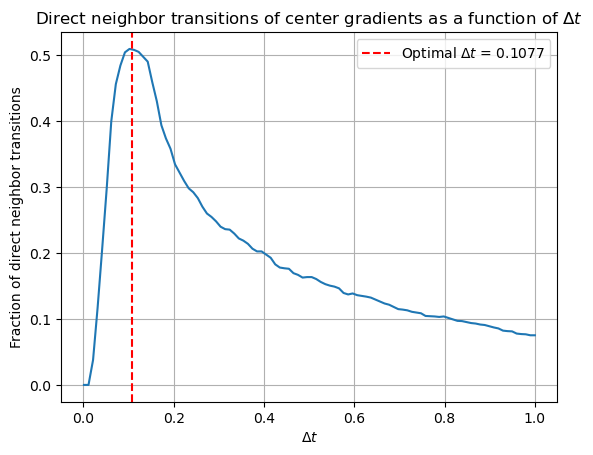

In [15]:
#New Solution!

fhnsimulator = Simulator(fhngrid, fmodel, fsolver)
fhnsimulator.get_optimal_delta_t(controls, (0.001,1), '../tests/optimal_delta_t_fhn.png')


In [16]:

avgdistancetoborder = 0.57389678 * fhngridcellwidth
print(avgdistancetoborder)
sorted_vector_lengths = compute_gradient_vector_lengths(transformed_derivatives)

0.019129892666666665


In [17]:
coverage_function = create_coverage_function(sorted_vector_lengths, avgdistancetoborder)
optimal_t, max_fraction = find_optimal_timestep(coverage_function, bounds = (0.05, 10))
print(f"Fraction of shorter gradient lengths: {100*np.mean(sorted_vector_lengths<avgdistancetoborder/optimal_t):.2f}%")
print(f"Fraction of longer gradient lengths: {100*np.mean(sorted_vector_lengths>3*avgdistancetoborder/optimal_t):.2f}%")


Optimal t: 0.1306
Max fraction of data in interval: 51.89%
Fraction of shorter gradient lengths: 30.52%
Fraction of longer gradient lengths: 17.59%


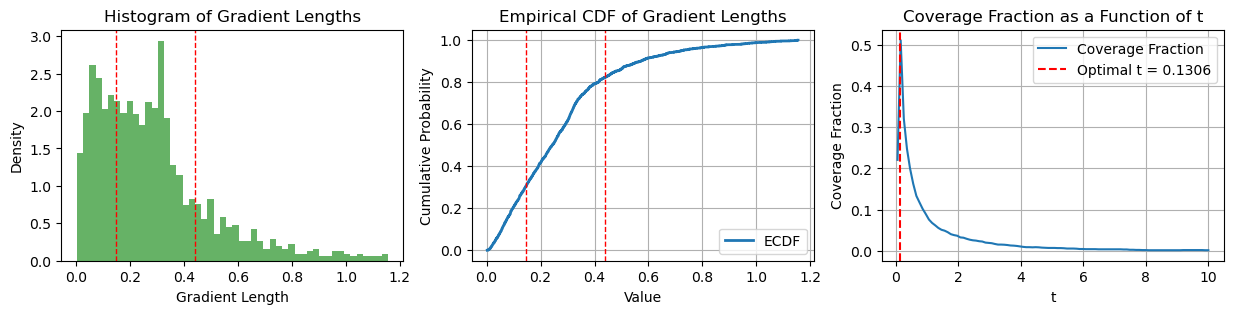

In [18]:

fig, axes = plt.subplots(1,3, figsize=(15,3))
plot_gradient_length_distribution(axes, avgdistancetoborder, sorted_vector_lengths, stepsize=optimal_t)
plot_coverage_fraction(axes[2], coverage_function, (0.05,10), optimal_t) # plot 2 mit log, delta t verwenden

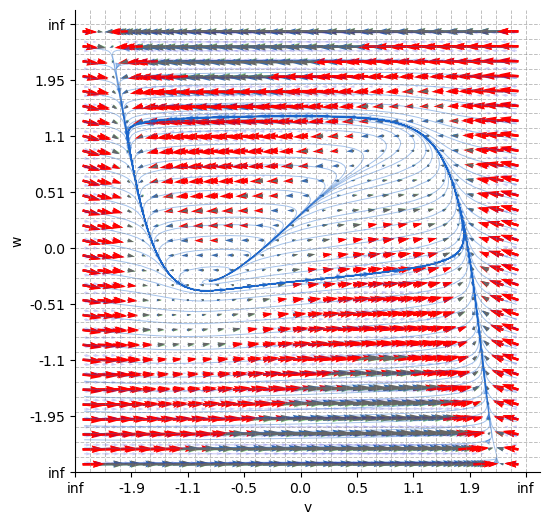

In [19]:
fig, axes = plt.subplots(figsize=(6, 6))
plot_grid_gradients(axes, fhngrid, fsolver, controls, transformed_centers, optimal_t * transformed_derivatives, highlight_range=(avgdistancetoborder, 3*avgdistancetoborder))
plot_2D_vector_field_over_grid(fhngrid, fsolver, control = controls[0], axis_names=['v','w'], 
                                title='', display_nullclines=False, 
                                ax = axes, display_grid=True, 
                                display_streamplot= True,
                                broken_streamlines=False, streamplot_colour=(0.1,0.4,0.8,0.4))

### Countertest with Cell-based Calculations

Optimal t: 0.1047
Max fraction of data in interval: 51.33%
********Test with cell-based calculations***********
Given a timestep of 0.1047
Gradient vectors which do not leave the cell: 33.93%
Gradient vectors which go to the next cell: 51.33%
Gradient vectors which jump over the next cell: 14.74%
*****************************************************
********Test with cell-based calculations***********
Given a timestep of 0.1306
Gradient vectors which do not leave the cell: 27.78%
Gradient vectors which go to the next cell: 50.15%
Gradient vectors which jump over the next cell: 22.07%
*****************************************************


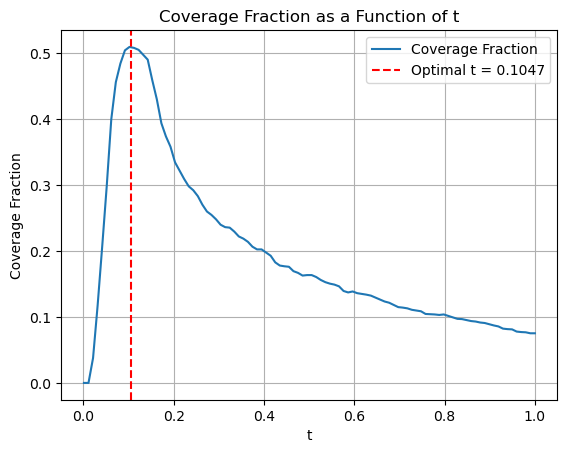

In [20]:
nb_transition_fraction = create_neighbor_transition_function(transformed_derivatives, fhngridcellwidth)
optimal_step, m = find_optimal_timestep(nb_transition_fraction, (0.001,10))
print_countertest_transition_fractions(transformed_derivatives, fhngridcellwidth, optimal_step)
print_countertest_transition_fractions(transformed_derivatives, fhngridcellwidth, optimal_t)
fig, axes = plt.subplots()
plot_coverage_fraction(axes, nb_transition_fraction, (0.001,1), optimal_step)

## Technology Substitution

In [18]:
tmodel = TechnologySubstitution(D0=1.0, delta=1.0, sigma=0.2, alpha=0.5, gamma1=1.0)
tsolver = TechSubNumericalSolver(tmodel)
tinfbounds = [(0, np.inf), (0, np.inf)]
tres = [50,50]
fract_trafos = [fractional_transformation(0.3), fractional_transformation(0.3)]
tgrid = Grid(tinfbounds, tres, fract_trafos)
tcontrols = np.array([0.5, 1])

In [19]:
tcenters, ttransformed_centers, tderivatives, ttransformed_derivatives = get_gridcell_centers_and_derivatives(tgrid,tsolver, tcontrols)

In [20]:
tgridcellwidth = 1/tres[0]
tavgdistancetoborder = 0.57389678 * tgridcellwidth
tsorted_vector_lengths = compute_gradient_vector_lengths(ttransformed_derivatives)

In [21]:
tcoverage_function = create_coverage_function(tsorted_vector_lengths, tavgdistancetoborder)
toptimal_t, max_fraction = find_optimal_timestep(tcoverage_function, bounds = (0.1, 10))
print(f"Fraction of shorter gradient lengths: {100*np.mean(tsorted_vector_lengths<tavgdistancetoborder/toptimal_t):.2f}%")
print(f"Fraction of longer gradient lengths: {100*np.mean(tsorted_vector_lengths>3*tavgdistancetoborder/toptimal_t):.2f}%")

Optimal t: 0.6294
Max fraction of data in interval: 44.68%
Fraction of shorter gradient lengths: 25.80%
Fraction of longer gradient lengths: 29.52%


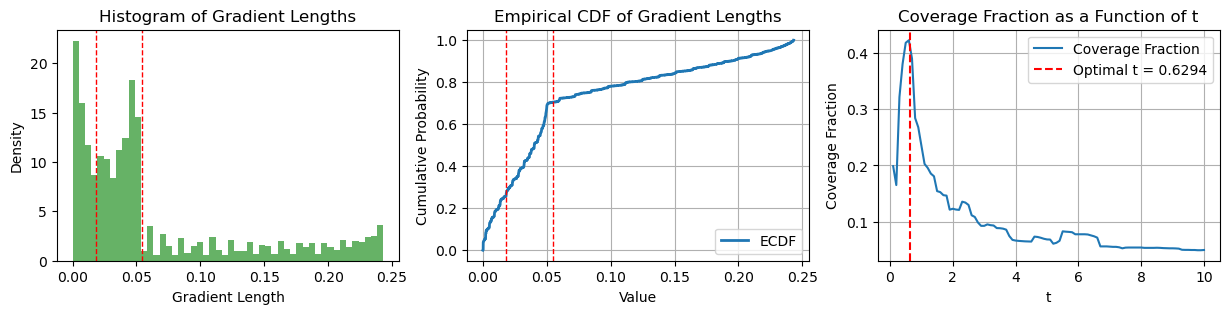

In [22]:
fig, axes = plt.subplots(1,3, figsize=(15,3))
plot_gradient_length_distribution(axes, tavgdistancetoborder, tsorted_vector_lengths, stepsize=toptimal_t)
plot_coverage_fraction(axes[2], tcoverage_function, (0.1,10), toptimal_t)

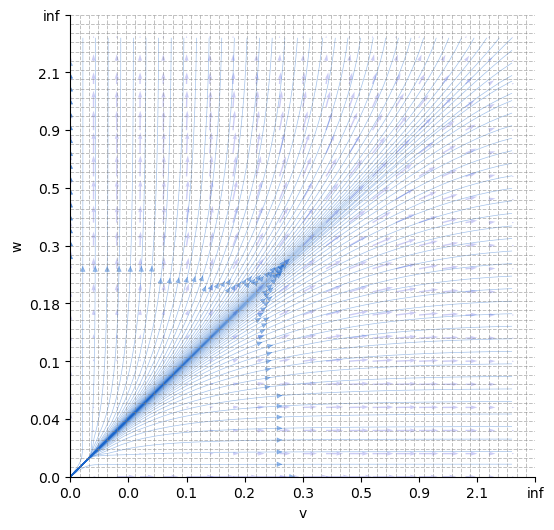

In [25]:
fig, axes = plt.subplots(figsize=(6, 6))
plot_2D_vector_field_over_grid(tgrid, tsolver, control = tcontrols[1], axis_names=['v','w'], 
                                title='', display_nullclines=False, 
                                resolution = 21,
                                ax = axes, display_grid=True, 
                                display_streamplot= True,
                                broken_streamlines=False, streamplot_colour=(0.1,0.4,0.8,0.4),
                                display_vectorfield_magnitude=False)
neighbor_range = (tavgdistancetoborder, 3*tavgdistancetoborder)
#plot_grid_gradients(axes, tgrid, tsolver, tcontrols, ttransformed_centers, toptimal_t*ttransformed_derivatives, highlight_range=neighbor_range,)

### Countertest with Cell-based Calculations

Optimal t: 0.5972
Max fraction of data in interval: 44.72%
********Test with cell-based calculations***********
Given a timestep of 0.5972
Gradient vectors which do not leave the cell: 26.16%
Gradient vectors which go to the next cell: 44.72%
Gradient vectors which jump over the next cell: 29.12%
*****************************************************
********Test with cell-based calculations***********
Given a timestep of 0.6294
Gradient vectors which do not leave the cell: 25.44%
Gradient vectors which go to the next cell: 38.56%
Gradient vectors which jump over the next cell: 36.00%
*****************************************************


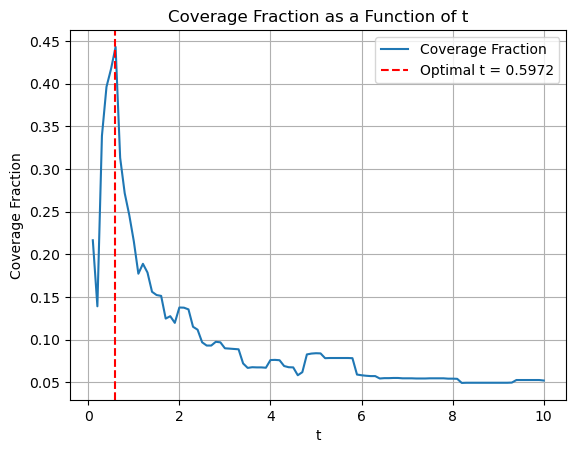

In [24]:
tnb_transition_fraction = create_neighbor_transition_function(ttransformed_derivatives, tgridcellwidth)
toptimal_step, m = find_optimal_timestep(tnb_transition_fraction, (0.1,10))
print_countertest_transition_fractions(ttransformed_derivatives, tgridcellwidth, toptimal_step)
print_countertest_transition_fractions(ttransformed_derivatives, tgridcellwidth, toptimal_t)
fig, axes = plt.subplots()
plot_coverage_fraction(axes, tnb_transition_fraction, (0.1,10), toptimal_step)